In [5]:
#IMPORT THE NECESSARY LIBRARIES TO READ AND PROCESS THE RAW DATA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
#LOAD DATA FROM THE LOCAL MACHINE
df = pd.read_csv("C:/Data/new.csv")

In [9]:
# check the description of the data
print(df.head())
print(df.info())

   Unnamed: 0                                           headline  \
0           0            Stocks That Hit 52-Week Highs On Friday   
1           1         Stocks That Hit 52-Week Highs On Wednesday   
2           2                      71 Biggest Movers From Friday   
3           3       46 Stocks Moving In Friday's Mid-Day Session   
4           4  B of A Securities Maintains Neutral on Agilent...   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   
3  https://www.benzinga.com/news/20/05/16095921/4...         Lisa Levin   
4  https://www.benzinga.com/news/20/05/16095304/b...         Vick Meyer   

                        date stock  
0  2020-06-05 10:30:54-04:00     A  
1  2020-06-03 10:45:20-04:00     A  
2  2020-05-26 04:30:07-04:00 

In [10]:
#IMPLEMENTING DATA CLEANING ON THE RAW DATA INCLUDING REPLACING THE 
df['date'] = pd.to_datetime(df['date'], errors='coerce')


In [11]:
#DROP THE ROW WITH INVALID DATE COLUMN OR REMOVE INVALID DATE FROM THE RAW DATA
df = df.dropna(subset=['date'])

In [12]:
#PERFORMING THE COUNT OPERATION STATICALLY IN BOTH WORD AND CHARACTER
df['headline_length'] = df['headline'].astype(str).apply(len)

In [13]:
#PERFOMING THE STATISTICALL COUNT ON THE HEADLINE
print(df['headline_length'].describe())

count    55987.000000
mean        80.015254
std         56.126094
min         12.000000
25%         42.000000
50%         63.000000
75%         91.000000
max        512.000000
Name: headline_length, dtype: float64


In [14]:
plt.figure()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

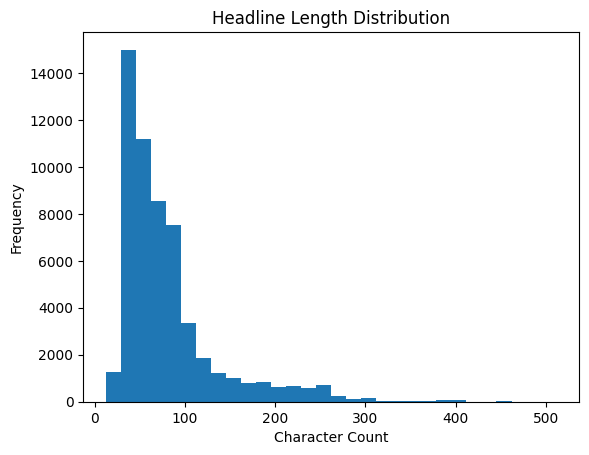

In [15]:
#How many headlines fall into each length range
plt.hist(df['headline_length'], bins=30)

plt.title("Headline Length Distribution")
#This axis shows headline length (in characters)
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.show()

In [16]:
#THE FOLLOWING CODE SHOWS WHICH SOURCES ARE MOST ACTIVE.
publisher_counts = df['publisher'].value_counts()


In [17]:
#shows the top 10 most active news publishers.
print(publisher_counts.head(10))

publisher
Benzinga Newsdesk    14750
Lisa Levin           12408
ETF Professor         4362
Paul Quintaro         4212
Benzinga Newsdesk     3177
Benzinga Insights     2332
Vick Meyer            2128
Charles Gross         1790
Hal Lindon            1470
Benzinga_Newsdesk     1239
Name: count, dtype: int64


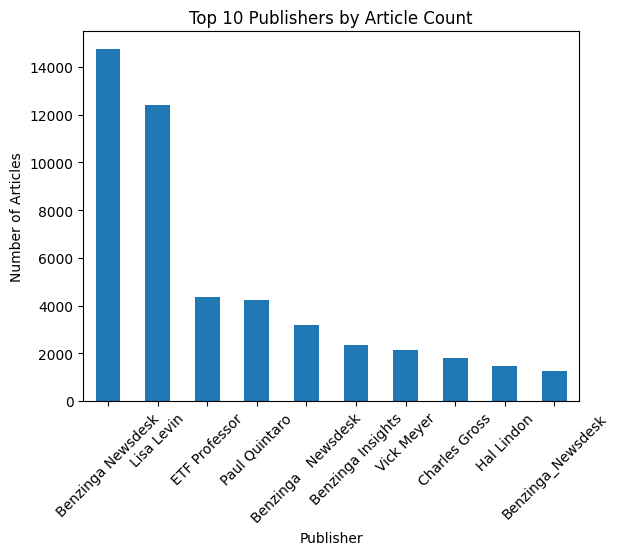

In [18]:
#THE FOLLOWIING CODE SHOWS THE ACTIVE NEWS PUBLISHER GRAPHICALLY.
plt.figure()
publisher_counts.head(10).plot(kind='bar')
plt.title("Top 10 Publishers by Article Count")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.show()

In [19]:
#THE FOLLOWING CODE DISPLAYS THE PUBLICATION TREND BASED ON DIFFERENT EFFECTS.
#How news activity changes over time
#Whether there are bursts of publishing
#Overall market/news intensity
daily_counts = df.groupby(df['date'].dt.date).size()

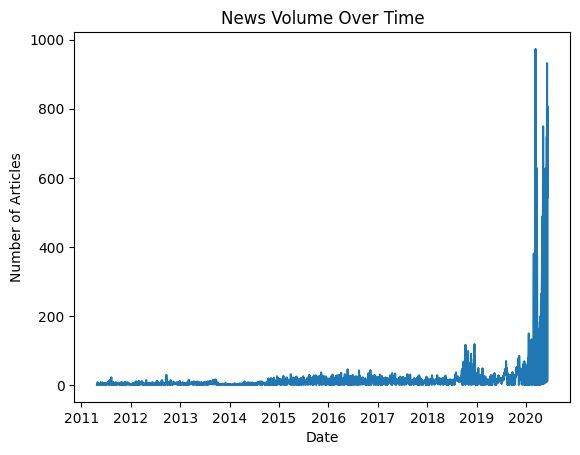

In [20]:
plt.figure()
daily_counts.plot()
plt.title("News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.show()

In [21]:
#THE AVERAGE OF NEWS PUBLISHED WITHIN A DAY OVER A YEARS 
#Spikes = days where:

#actual volume is far above rolling average

#These often correspond to:

#earnings announcements
#major policy news
#geopolitical events
#market crashes or rallies
rolling = daily_counts.rolling(window=7).mean()

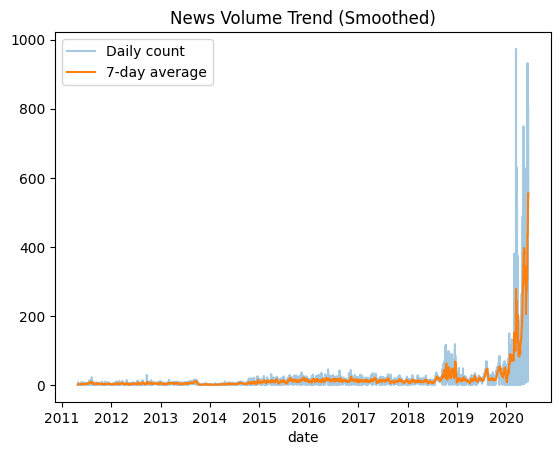

In [22]:
plt.figure()
daily_counts.plot(alpha=0.4, label="Daily count")
rolling.plot(label="7-day average")
plt.legend()
plt.title("News Volume Trend (Smoothed)")
plt.show()

In [39]:
#the following line of code counts a news published per hour
df['hour'] = df['date'].dt.hour

In [40]:
hour_counts = df['hour'].value_counts().sort_index()

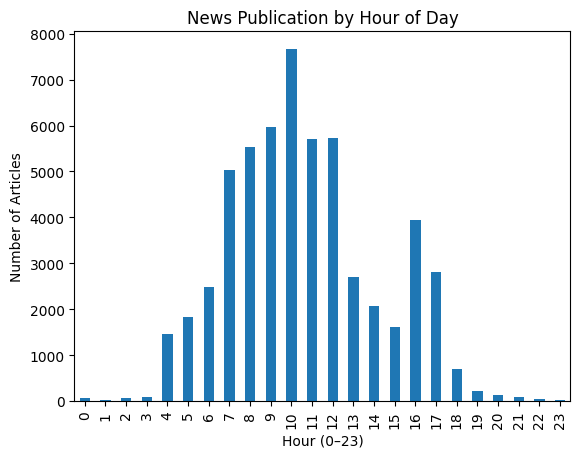

In [41]:
plt.figure()
hour_counts.plot(kind='bar')
plt.title("News Publication by Hour of Day")
plt.xlabel("Hour (0–23)")
plt.ylabel("Number of Articles")
plt.show()

In [23]:
#DEFINE THE DETAILS NEWS(TEXT) IN THE NEWS
df['headline']

0                    Stocks That Hit 52-Week Highs On Friday
1                 Stocks That Hit 52-Week Highs On Wednesday
2                              71 Biggest Movers From Friday
3               46 Stocks Moving In Friday's Mid-Day Session
4          B of A Securities Maintains Neutral on Agilent...
                                 ...                        
1407266    Chinese Nano-Cap Momentum Stocks Sharply Highe...
1407267    28 Stocks Moving In Wednesday's Pre-Market Ses...
1407268    China Zenix Auto International Reports Q3 EPAD...
1407269                     46 Biggest Movers From Yesterday
1407270        42 Stocks Moving In Tuesday's Mid-Day Session
Name: headline, Length: 55987, dtype: str

In [24]:
#IMPORT THE NECESSARY LIBERARIRIES IN TEXT PROCESSING 
import pandas as pd
import re

In [25]:
#CLEAN THE TEXT INCLUDING REMOVING DIFFERENT PUNCTUATION MARKS IN THE TEXT(NEWS) ETC..
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)  # remove numbers & punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [26]:
df['clean_headline'] = df['headline'].apply(clean_text)

In [32]:
#Convert text into numerical form (CountVectorizer)
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english', max_features=5000)
X_counts = vectorizer.fit_transform(df['clean_headline'])

In [33]:
#this line of code shows the commonly used words in news among the ten publisher
import numpy as np

word_counts = np.asarray(X_counts.sum(axis=0)).flatten()
words = vectorizer.get_feature_names_out()

word_freq = pd.DataFrame({
    'word': words,
    'count': word_counts
}).sort_values(by='count', ascending=False)

print(word_freq.head(20))

           word  count
4265     stocks  12796
4848       week   8959
4034     shares   8375
4567    trading   6574
2078        hit   5898
1511        eps   5530
3472      price   5043
946   companies   4778
4416     target   4675
3914      sales   4422
2059     higher   4269
2713     market   4025
1535   estimate   3818
2650       lows   3741
4020    session   3394
2678  maintains   3266
3000        new   3107
4973  yesterday   3049
3752    reports   3016
2912     moving   2867


In [34]:
#THE TF-IDF SHOWS THE MOST COMMON WORDS IN THE NEWS BUT NOT EVERYWHERE
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_headline'])

In [35]:
feature_array = np.array(tfidf.get_feature_names_out())
tfidf_scores = np.asarray(X_tfidf.mean(axis=0)).flatten()

tfidf_df = pd.DataFrame({
    'word': feature_array,
    'score': tfidf_scores
}).sort_values(by='score', ascending=False)

print(tfidf_df.head(20))

           word     score
4265     stocks  0.059734
4848       week  0.050418
2078        hit  0.044099
2650       lows  0.031957
4973  yesterday  0.023317
2066      highs  0.023172
1511        eps  0.023067
495     biggest  0.023000
4506   thursday  0.022773
2910     movers  0.021706
4020    session  0.021096
4034     shares  0.020808
2912     moving  0.020142
1798     friday  0.019717
1535   estimate  0.019264
3472      price  0.019259
4416     target  0.018603
3914      sales  0.018117
4567    trading  0.017809
3000        new  0.016044


In [36]:
#Now we extract Tthe hidden themes/topics automatically using LDA NLP Algorithm
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X_counts)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [37]:
#for instance, the following code shows the name of the  topic of news 
def show_topics(model, feature_names, n_words=10):
    for idx, topic in enumerate(model.components_):
        print(f"\nTopic {idx + 1}")
        print([feature_names[i] for i in topic.argsort()[-n_words:]])

show_topics(lda, vectorizer.get_feature_names_out())


Topic 1
['wednesday', 'etf', 'etfs', 'friday', 'thursday', 'highs', 'lows', 'hit', 'week', 'stocks']

Topic 2
['coronavirus', 'earnings', 'economic', 'following', 'lower', 'amid', 'higher', 'companies', 'trading', 'shares']

Topic 3
['market', 'yesterday', 'premarket', 'midday', 'movers', 'shares', 'biggest', 'moving', 'session', 'stocks']

Topic 4
['company', 'miss', 'beat', 'beats', 'announces', 'reports', 'yoy', 'estimate', 'sales', 'eps']

Topic 5
['downgrades', 'week', 'stocks', 'set', 'raises', 'vs', 'new', 'maintains', 'target', 'price']


In [38]:
daily_counts = df.groupby(df['date'].dt.date).size()

In [42]:
#Count number of articles per publisher 
publisher_counts = df['publisher'].value_counts()

print(publisher_counts.head(10))

publisher
Benzinga Newsdesk    14750
Lisa Levin           12408
ETF Professor         4362
Paul Quintaro         4212
Benzinga Newsdesk     3177
Benzinga Insights     2332
Vick Meyer            2128
Charles Gross         1790
Hal Lindon            1470
Benzinga_Newsdesk     1239
Name: count, dtype: int64


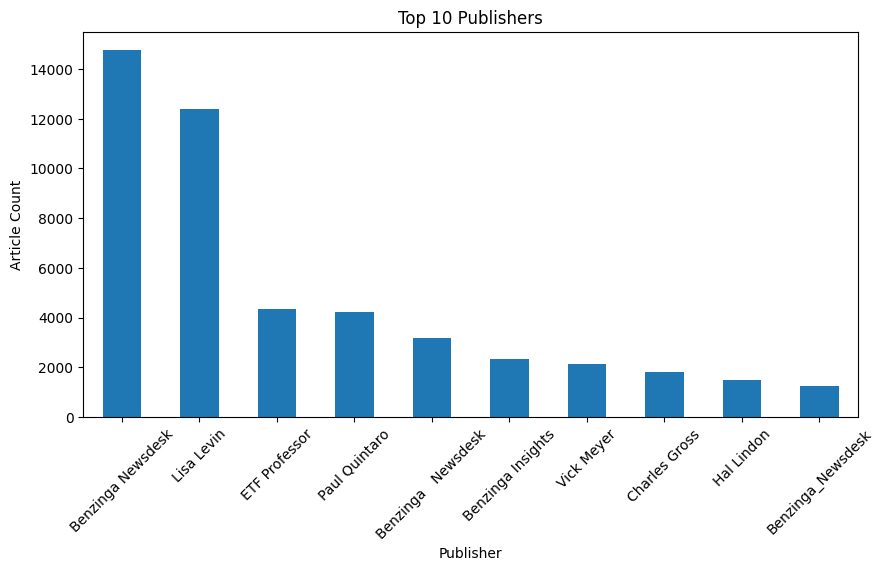

In [43]:
#the following plot show the diagramatical representation of number articles with their publisher
plt.figure(figsize=(10,5))
publisher_counts.head(10).plot(kind='bar')

plt.title("Top 10 Publishers")
plt.xlabel("Publisher")
plt.ylabel("Article Count")

plt.xticks(rotation=45)
plt.show()

In [44]:
#the headline length of the topics of the news with the publisher
publisher_stats = df.groupby('publisher')['headline_length'].mean()

print(publisher_stats.sort_values(ascending=False).head(10))

publisher
Benzinga Newsdesk        226.071766
Benzinga  Newsdesk       175.562500
Investor Ideas           122.000000
Othanas Economopoulos    115.000000
luke@benzinga.com        106.804428
Early Global News        106.111111
Christina Jackson        102.857143
Shanthi Rexaline         102.629087
Christopher Sappo        102.500000
Benzinga Pro Newsdesk    102.500000
Name: headline_length, dtype: float64


In [45]:
#the following line code of displays the email domain of the publisher
df['domain'] = df['publisher'].str.extract(r'@([\w\.-]+)')

In [46]:
domain_counts = df['domain'].value_counts()

print(domain_counts.head(10))

domain
benzinga.com    1196
gmail.com          3
Name: count, dtype: int64


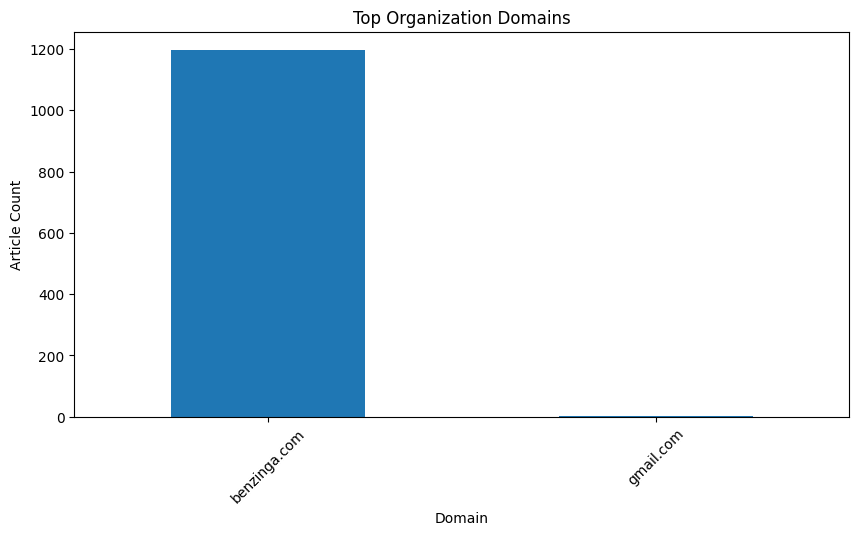

In [47]:
plt.figure(figsize=(10,5))

domain_counts.head(10).plot(kind='bar')

plt.title("Top Organization Domains")
plt.xlabel("Domain")
plt.ylabel("Article Count")

plt.xticks(rotation=45)
plt.show()